# ALIKED+LightGlue length-5 track triangulation

This notebook loads one cleaned ALIKED+LightGlue feature track from the `eval_utils` evaluation inputs, visualizes its five observations on image crops, triangulates the 3D point from the first four observations, reprojects it into all five crops, and reports the held-out reprojection error for the fifth observation.


In [61]:
from pathlib import Path
import importlib.util
import itertools
import sys

import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd()
if not (REPO / "eval_utils").exists():
    REPO = Path("/home/roger/sat-bundleadjust_github")

for path in [REPO, REPO / "notebooks"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from utils_vis_tracks import extract_crop, read_image_for_display
from bundle_adjust import geo_utils
from bundle_adjust.feature_tracks.ft_triangulate import init_pts3d

helper_path = REPO / "eval_utils" / "prepare_inputs" / "evaluate_heldout_fixed_rpcs_least_similar_pairs.py"
spec = importlib.util.spec_from_file_location("eval_helper", helper_path)
helper = importlib.util.module_from_spec(spec)
spec.loader.exec_module(helper)

print(f"Repo: {REPO}")


Repo: /home/roger/sat-bundleadjust_github


In [62]:
# Configuration. Leave AOI_ID as None to use the first available AOI with a cleaned length-5 track.
FEATURE_TYPE = "aliked" # "aliked" or "superpoint"
LEAST_PAIR_RANKING_K = 5
PAIR_SELECTION_MODE = "least" # "least" or "most"
AOI_ID = None
TRACK_CHOICE = 0
CROP_RADIUS = 96

# Figure typography. This mirrors similarity_study_figure_final.ipynb:
# serif text, STIX math, and embedded TrueType fonts. Set USE_EXTERNAL_LATEX=True
# only if your notebook environment has a full LaTeX installation.
USE_EXTERNAL_LATEX = False
FIGURE_FONT_SIZE = 16
FIGURE_TITLE_SIZE = 18
FIGURE_PANEL_TITLE_SIZE = 16
FIGURE_LEGEND_SIZE = 15
FIGURE_FAMILY = ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"]

plt.rcParams.update({
    "text.usetex": USE_EXTERNAL_LATEX,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "serif",
    "font.serif": FIGURE_FAMILY,
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": FIGURE_FONT_SIZE,
    "axes.titlesize": FIGURE_TITLE_SIZE,
    "axes.labelsize": FIGURE_FONT_SIZE,
    "xtick.labelsize": FIGURE_FONT_SIZE,
    "ytick.labelsize": FIGURE_FONT_SIZE,
    "legend.fontsize": FIGURE_LEGEND_SIZE,
})

def latex_escape(value):
    return str(value).replace("_", r"\_")

# Track selection filter, measured after triangulating from observations 1-4
# and reprojecting into all 5 observations. TRACK_CHOICE selects the N-th
# passing track after this filter.
MIN_CAMERAS_BELOW_GOOD_REPROJ_PX = 3
GOOD_REPROJ_THRESHOLD_PX = 1.0
MAX_REPROJ_THRESHOLD_PX = 1.2

# Choose which RPC set to use for triangulation, optimization, and reprojection.
# Options: "raw", "ames", "satba", "my".
RPC_KIND = "my"
keypt2subpx = True

if PAIR_SELECTION_MODE not in {"least", "most"}:
    raise ValueError(f"PAIR_SELECTION_MODE must be 'least' or 'most', got {PAIR_SELECTION_MODE!r}")

EVAL_INPUTS_ROOT = REPO / "EVAL" / "inputs"
MATCHING_ROOT = EVAL_INPUTS_ROOT / f"{FEATURE_TYPE}_lightglue_matching"

if keypt2subpx:
    MATCHING_ROOT = EVAL_INPUTS_ROOT / f"{FEATURE_TYPE}_lightglue_matching_keypt2subpx"

# Same RPC path templates as eval_utils/eval_least_similarK5_clean_tracks_image_outlier.sh.
RPC_DIR_TEMPLATES = {
    "raw": REPO / "DATA" / "data_ready_full" / "OMA" / "{aoi}" / "rpcs",
    "ames": Path("/home/roger/ames_ba/outputs_Cauchy_SIFT") / "{aoi}" / "adjusted_rpcs",
    "satba": REPO / "LOGS" / "exhaustive_eval_full" / "OMA_newnew" / "{aoi}" / "opencv-flann-baseline" / "ba_bruteforce" / "rpcs_adj",
    "my": REPO / "LOGS" / "exhaustive_eval_full" / "OMA_newnew" / "{aoi}" / "-lightglue_superpoint-bestpairs-K5" / "ba_bruteforce" / "rpcs_adj",
}

def matches_dir_for(aoi):
    return MATCHING_ROOT / aoi

def track_dir_name():
    return f"tracks_{PAIR_SELECTION_MODE}_similar_K{LEAST_PAIR_RANKING_K}"

def cleaned_tracks_dir_for(aoi):
    return matches_dir_for(aoi) / track_dir_name() / "cleaned_tracks_consensus_thr3"

def rpc_dir_for(aoi, rpc_kind=RPC_KIND):
    if rpc_kind not in RPC_DIR_TEMPLATES:
        valid = ", ".join(sorted(RPC_DIR_TEMPLATES))
        raise ValueError(f"Unsupported RPC_KIND={rpc_kind!r}. Choose one of: {valid}")
    return Path(str(RPC_DIR_TEMPLATES[rpc_kind]).format(aoi=aoi))


In [63]:
def load_image_paths(matches_dir):
    image_paths_txt = matches_dir / "image_paths.txt"
    with image_paths_txt.open("r", encoding="utf-8") as f:
        return [Path(line.strip()) for line in f if line.strip()]

def track_length(C):
    return np.sum(np.isfinite(C[::2, :]), axis=0).astype(int)

def observations_from_C_column(C, track_idx, image_paths_for_aoi):
    obs = []
    n_images = C.shape[0] // 2
    for image_idx in range(n_images):
        col = C[2 * image_idx, track_idx]
        row = C[2 * image_idx + 1, track_idx]
        if np.isfinite(col) and np.isfinite(row):
            obs.append({
                "image_idx": int(image_idx),
                "image_path": image_paths_for_aoi[image_idx],
                "col": float(col),
                "row": float(row),
            })
    return obs

def triangulate_first4_and_reproject_errors(C_for_aoi, obs_for_track, rpcs_for_aoi):
    train = obs_for_track[:4]
    train_image_indices = [item["image_idx"] for item in train]
    train_pairs = [(i, j) for i, j in itertools.combinations(train_image_indices, 2)]

    C_train = np.full((C_for_aoi.shape[0], 1), np.nan, dtype=np.float64)
    for item in train:
        image_idx = item["image_idx"]
        C_train[2 * image_idx, 0] = item["col"]
        C_train[2 * image_idx + 1, 0] = item["row"]

    pts_ecef = init_pts3d(
        C=C_train,
        cameras=rpcs_for_aoi,
        cam_model="rpc",
        pairs_to_triangulate=train_pairs,
        verbose=False,
    )
    lon_lat_alt_i = helper.ecef_xyz_to_lon_lat_alt(np.asarray(pts_ecef, dtype=np.float64), geo_utils)[0]
    if not np.all(np.isfinite(lon_lat_alt_i)):
        return None, None

    lon_i, lat_i, alt_i = map(float, lon_lat_alt_i)
    errors = []
    for item in obs_for_track:
        image_idx = item["image_idx"]
        proj_col, proj_row = helper.project_rpc_safe(rpcs_for_aoi[image_idx], lon_i, lat_i, alt_i)
        errors.append(float(np.hypot(proj_col - item["col"], proj_row - item["row"])))
    return lon_lat_alt_i, np.asarray(errors, dtype=np.float64)

def track_passes_reprojection_filter(errors):
    if errors is None or errors.shape[0] != 5 or not np.all(np.isfinite(errors)):
        return False
    n_good = int(np.sum(errors < GOOD_REPROJ_THRESHOLD_PX))
    max_error = float(np.max(errors))
    return n_good >= MIN_CAMERAS_BELOW_GOOD_REPROJ_PX and max_error <= MAX_REPROJ_THRESHOLD_PX

def find_filtered_length5_track():
    if AOI_ID is not None:
        candidates = [AOI_ID]
    else:
        candidates = sorted(p.name for p in MATCHING_ROOT.iterdir() if p.is_dir())

    checked = []
    passing_count = 0

    for candidate_aoi in candidates:
        c_path = cleaned_tracks_dir_for(candidate_aoi) / "cleaned_C.npy"
        checked.append(c_path)
        if not c_path.exists():
            continue

        C_candidate = np.asarray(np.load(c_path), dtype=np.float64)
        length5 = np.flatnonzero(track_length(C_candidate) == 5)
        if length5.size == 0:
            continue

        candidate_matches_dir = matches_dir_for(candidate_aoi)
        candidate_image_paths = load_image_paths(candidate_matches_dir)
        candidate_rpcs = helper.load_rpcs_for_images(rpc_dir_for(candidate_aoi), candidate_image_paths)

        print(
            f"Scanning {candidate_aoi}: {length5.size} length-5 tracks "
            f"for reprojection filter"
        )

        for candidate_track_idx in length5:
            candidate_track_idx = int(candidate_track_idx)
            candidate_obs = observations_from_C_column(
                C_candidate,
                candidate_track_idx,
                candidate_image_paths,
            )
            _, candidate_errors = triangulate_first4_and_reproject_errors(
                C_candidate,
                candidate_obs,
                candidate_rpcs,
            )
            if not track_passes_reprojection_filter(candidate_errors):
                continue

            if passing_count == TRACK_CHOICE:
                return (
                    candidate_aoi,
                    candidate_track_idx,
                    C_candidate,
                    candidate_image_paths,
                    candidate_rpcs,
                    candidate_errors,
                )
            passing_count += 1

    first_checked = "\n".join(str(p) for p in checked[:5])
    raise RuntimeError(
        f"No cleaned {FEATURE_TYPE}+LightGlue length-5 track passed the reprojection filter under {MATCHING_ROOT}.\n"
        f"PAIR_SELECTION_MODE={PAIR_SELECTION_MODE}, keypt2subpx={keypt2subpx}.\n"
        f"Filter: at least {MIN_CAMERAS_BELOW_GOOD_REPROJ_PX}/5 errors < "
        f"{GOOD_REPROJ_THRESHOLD_PX}px and max error <= {MAX_REPROJ_THRESHOLD_PX}px.\n"
        f"Passing tracks before requested TRACK_CHOICE={TRACK_CHOICE}: {passing_count}.\n"
        f"First cleaned_C paths checked:\n{first_checked}"
    )

aoi, track_idx, C, image_paths, rpcs, selection_errors = find_filtered_length5_track()
matches_dir = matches_dir_for(aoi)
cleaned_tracks_dir = cleaned_tracks_dir_for(aoi)
rpc_dir = rpc_dir_for(aoi)

print(f"AOI: {aoi}")
print(f"Track index: {track_idx}")
print(f"Pair selection mode: {PAIR_SELECTION_MODE}")
print(f"Selection reprojection errors: {np.array2string(selection_errors, precision=3)} px")
print(
    f"Selection filter: {int(np.sum(selection_errors < GOOD_REPROJ_THRESHOLD_PX))}/5 errors "
    f"< {GOOD_REPROJ_THRESHOLD_PX}px, max={np.max(selection_errors):.3f}px"
)
print(f"Matches dir: {matches_dir}")
print(f"Cleaned tracks dir: {cleaned_tracks_dir}")
print(f"RPC dir ({RPC_KIND}): {rpc_dir}")
print(f"C shape: {C.shape}")


Loaded RPC files:
  OMA_042_001_RGB.tif -> OMA_042_001_RGB.rpc_adj
  OMA_042_002_RGB.tif -> OMA_042_002_RGB.rpc_adj
  OMA_042_003_RGB.tif -> OMA_042_003_RGB.rpc_adj
  OMA_042_004_RGB.tif -> OMA_042_004_RGB.rpc_adj
  OMA_042_006_RGB.tif -> OMA_042_006_RGB.rpc_adj
  OMA_042_007_RGB.tif -> OMA_042_007_RGB.rpc_adj
  OMA_042_009_RGB.tif -> OMA_042_009_RGB.rpc_adj
  OMA_042_010_RGB.tif -> OMA_042_010_RGB.rpc_adj
  OMA_042_011_RGB.tif -> OMA_042_011_RGB.rpc_adj
  OMA_042_012_RGB.tif -> OMA_042_012_RGB.rpc_adj
  OMA_042_013_RGB.tif -> OMA_042_013_RGB.rpc_adj
  OMA_042_014_RGB.tif -> OMA_042_014_RGB.rpc_adj
  OMA_042_015_RGB.tif -> OMA_042_015_RGB.rpc_adj
  OMA_042_016_RGB.tif -> OMA_042_016_RGB.rpc_adj
  OMA_042_017_RGB.tif -> OMA_042_017_RGB.rpc_adj
  OMA_042_018_RGB.tif -> OMA_042_018_RGB.rpc_adj
  OMA_042_019_RGB.tif -> OMA_042_019_RGB.rpc_adj
  OMA_042_020_RGB.tif -> OMA_042_020_RGB.rpc_adj
  OMA_042_021_RGB.tif -> OMA_042_021_RGB.rpc_adj
  OMA_042_022_RGB.tif -> OMA_042_022_RGB.rpc_adj
  

In [64]:
def observations_from_C(C, track_idx):
    obs = []
    n_images = C.shape[0] // 2
    for image_idx in range(n_images):
        col = C[2 * image_idx, track_idx]
        row = C[2 * image_idx + 1, track_idx]
        if np.isfinite(col) and np.isfinite(row):
            obs.append({
                "image_idx": int(image_idx),
                "image_path": image_paths[image_idx],
                "col": float(col),
                "row": float(row),
            })
    return obs

obs = observations_from_C(C, track_idx)
assert len(obs) == 5, len(obs)
train_obs = obs[:4]
heldout_obs = obs[4]

for k, item in enumerate(obs, start=1):
    print(
        f"obs {k}: image_idx={item['image_idx']:02d}, "
        f"col={item['col']:.3f}, row={item['row']:.3f}, image={item['image_path'].name}"
    )
print(f"Held out: obs 5, image_idx={heldout_obs['image_idx']}")


obs 1: image_idx=04, col=728.692, row=913.088, image=OMA_042_006_RGB.tif
obs 2: image_idx=05, col=711.501, row=906.482, image=OMA_042_007_RGB.tif
obs 3: image_idx=06, col=747.132, row=888.981, image=OMA_042_009_RGB.tif
obs 4: image_idx=09, col=754.696, row=884.626, image=OMA_042_012_RGB.tif
obs 5: image_idx=14, col=721.013, row=892.755, image=OMA_042_017_RGB.tif
Held out: obs 5, image_idx=14


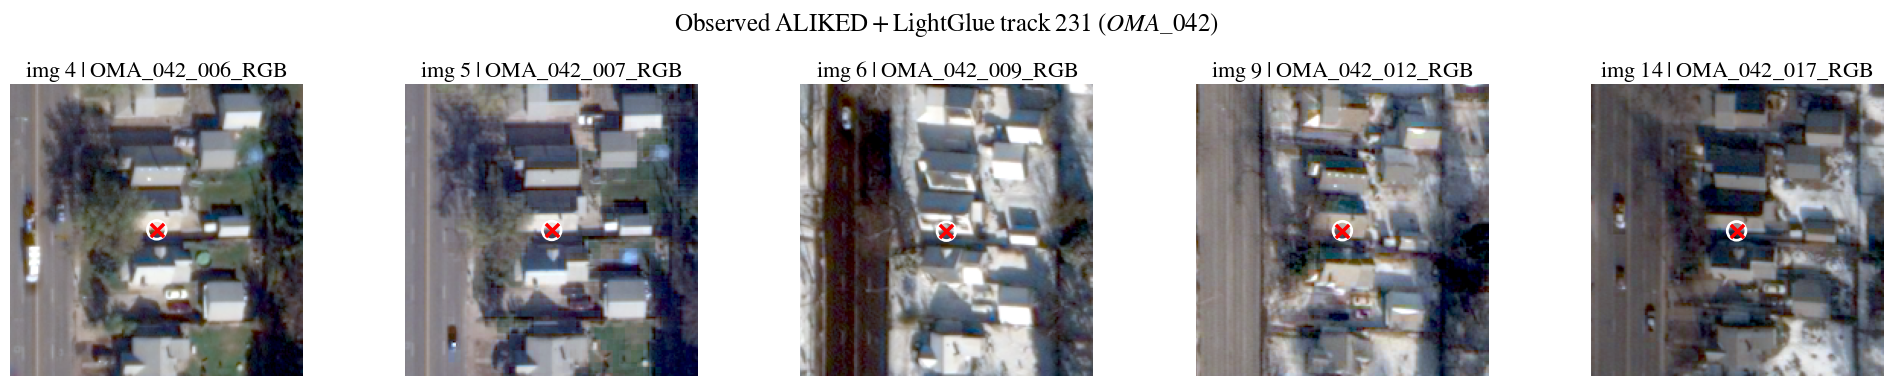

In [65]:
def plot_observed_track(observations, crop_radius=CROP_RADIUS):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for ax, item in zip(axes, observations):
        img = read_image_for_display(item["image_path"])
        crop, cx, cy = extract_crop(img, item["col"], item["row"], crop_radius)
        ax.imshow(crop, cmap="gray" if crop.ndim == 2 else None)
        ax.scatter([cx], [cy], marker="x", s=90, c="red", linewidths=2.5, zorder=3, label=r"$\mathrm{observation}$")
        ax.scatter([cx], [cy], s=180, facecolors="none", edgecolors="white", linewidths=2.0, zorder=2)
        image_stem = latex_escape(item["image_path"].stem)
        ax.set_title(
            rf"$\mathrm{{img}}\ {item['image_idx']}\;|\;\mathrm{{{image_stem}}}$",
            fontsize=FIGURE_PANEL_TITLE_SIZE,
        )
        ax.set_xlim(0, crop.shape[1])
        ax.set_ylim(crop.shape[0], 0)
        ax.set_aspect("equal")
        ax.axis("off")
    aoi_label = latex_escape(aoi)
    feature_label = latex_escape(FEATURE_TYPE.upper())
    fig.suptitle(
        rf"$\mathrm{{Observed}}\;\mathrm{{{feature_label}}}+\mathrm{{LightGlue}}\;\mathrm{{track}}\;{track_idx}\;({aoi_label})$",
        fontsize=FIGURE_TITLE_SIZE,
    )
    plt.tight_layout()
    plt.show()

plot_observed_track(obs)


In [66]:
# Triangulate from only the first four observations.
train_image_indices = [item["image_idx"] for item in train_obs]
train_pairs = [(i, j) for i, j in itertools.combinations(train_image_indices, 2)]

C_train = np.full((C.shape[0], 1), np.nan, dtype=np.float64)
for item in train_obs:
    image_idx = item["image_idx"]
    C_train[2 * image_idx, 0] = item["col"]
    C_train[2 * image_idx + 1, 0] = item["row"]

pts_ecef = init_pts3d(
    C=C_train,
    cameras=rpcs,
    cam_model="rpc",
    pairs_to_triangulate=train_pairs,
    verbose=True,
)
lon_lat_alt = helper.ecef_xyz_to_lon_lat_alt(np.asarray(pts_ecef, dtype=np.float64), geo_utils)[0]
lon, lat, alt = map(float, lon_lat_alt)

print(f"Triangulated lon/lat/alt from first 4 observations: {lon:.10f}, {lat:.10f}, {alt:.3f}")
print(f"Train image indices: {train_image_indices}")
print(f"Train pairs: {train_pairs}")


Computing 1 points 3d from feature tracks...
...6/6 triangulation pairs done in 0.01 seconds
done!
Triangulated lon/lat/alt from first 4 observations: -95.9562449678, 41.3108045609, 294.316
Train image indices: [4, 5, 6, 9]
Train pairs: [(4, 5), (4, 6), (4, 9), (5, 6), (5, 9), (6, 9)]


In [67]:
reprojected = []
for item in obs:
    image_idx = item["image_idx"]
    proj_col, proj_row = helper.project_rpc_safe(rpcs[image_idx], lon, lat, alt)
    error_px = float(np.hypot(proj_col - item["col"], proj_row - item["row"]))
    reprojected.append({**item, "proj_col": proj_col, "proj_row": proj_row, "error_px": error_px})

heldout_error_px = reprojected[4]["error_px"]
print(f"Held-out reprojection error, observation 5: {heldout_error_px:.3f} px")
print("All reprojection errors:")
for k, item in enumerate(reprojected, start=1):
    role = "held-out" if k == 5 else "train"
    print(f"  obs {k} ({role}, image_idx={item['image_idx']:02d}): {item['error_px']:.3f} px")


Held-out reprojection error, observation 5: 0.884 px
All reprojection errors:
  obs 1 (train, image_idx=04): 0.905 px
  obs 2 (train, image_idx=05): 0.710 px
  obs 3 (train, image_idx=06): 0.192 px
  obs 4 (train, image_idx=09): 0.776 px
  obs 5 (held-out, image_idx=14): 0.884 px


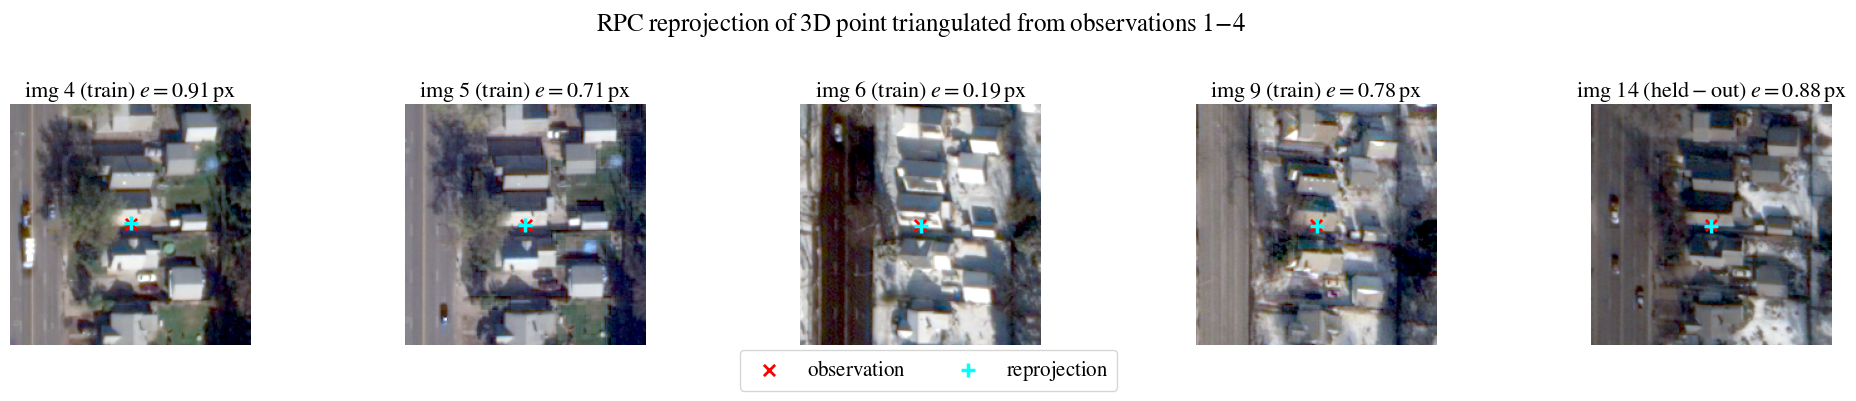

In [68]:
def plot_reprojected_track(items, crop_radius=CROP_RADIUS):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for k, (ax, item) in enumerate(zip(axes, items), start=1):
        img = read_image_for_display(item["image_path"])
        crop, obs_cx, obs_cy = extract_crop(img, item["col"], item["row"], crop_radius)
        x0 = item["col"] - obs_cx
        y0 = item["row"] - obs_cy
        proj_cx = item["proj_col"] - x0
        proj_cy = item["proj_row"] - y0

        ax.imshow(crop, cmap="gray" if crop.ndim == 2 else None)
        ax.scatter([obs_cx], [obs_cy], marker="x", s=65, c="red", linewidths=2.0, zorder=3, label=r"$\mathrm{observation}$")
        ax.scatter([proj_cx], [proj_cy], marker="+", s=110, c="cyan", linewidths=2.5, zorder=4, label=r"$\mathrm{reprojection}$")
        ax.plot([obs_cx, proj_cx], [obs_cy, proj_cy], color="yellow", linewidth=1.5, zorder=2)
        role = "held-out" if k == 5 else "train"
        role_label = latex_escape(role)
        ax.set_title(
            rf"$\mathrm{{img}}\ {item['image_idx']}\;(\mathrm{{{role_label}}})\;e={item['error_px']:.2f}\,\mathrm{{px}}$",
            fontsize=FIGURE_PANEL_TITLE_SIZE,
        )
        ax.set_xlim(0, crop.shape[1])
        ax.set_ylim(crop.shape[0], 0)
        ax.set_aspect("equal")
        ax.axis("off")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=FIGURE_LEGEND_SIZE)
    fig.suptitle(
        r"$\mathrm{RPC}\;\mathrm{reprojection}\;\mathrm{of}\;\mathrm{3D}\;\mathrm{point}\;\mathrm{triangulated}\;\mathrm{from}\;\mathrm{observations}\;1\! -\! 4$",
        fontsize=FIGURE_TITLE_SIZE,
    )
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()

plot_reprojected_track(reprojected)


## Optimize the triangulated 3D point

Starting from the RPC triangulation above, refine only the 3D point position by minimizing reprojection residuals on observations 1-4. Observation 5 remains held out and is used only for reporting.


In [69]:
from scipy.optimize import least_squares

initial_lon_lat_alt = np.array([lon, lat, alt], dtype=np.float64)
# Optimizer variables are dimensionless increments. The scales keep lon/lat/alt
# steps in comparable numerical ranges while residuals remain in pixels.
OPT_PARAM_SCALES = np.array([1e-5, 1e-5, 10.0], dtype=np.float64)

def project_point_to_items(lon_lat_alt, observations):
    lon_i, lat_i, alt_i = map(float, lon_lat_alt)
    projected_items = []
    for item in observations:
        image_idx = item["image_idx"]
        proj_col, proj_row = helper.project_rpc_safe(rpcs[image_idx], lon_i, lat_i, alt_i)
        error_px = float(np.hypot(proj_col - item["col"], proj_row - item["row"]))
        projected_items.append({
            **item,
            "proj_col": proj_col,
            "proj_row": proj_row,
            "error_px": error_px,
        })
    return projected_items

def train_reprojection_residuals(delta_scaled):
    candidate_lon_lat_alt = initial_lon_lat_alt + OPT_PARAM_SCALES * np.asarray(delta_scaled)
    residuals = []
    for item in train_obs:
        image_idx = item["image_idx"]
        proj_col, proj_row = helper.project_rpc_safe(rpcs[image_idx], *candidate_lon_lat_alt)
        residuals.extend([proj_col - item["col"], proj_row - item["row"]])
    return np.asarray(residuals, dtype=np.float64)

opt_result = least_squares(
    train_reprojection_residuals,
    x0=np.zeros(3, dtype=np.float64),
    loss="linear",
    xtol=1e-10,
    ftol=1e-10,
    gtol=1e-10,
    max_nfev=200,
)

optimized_lon_lat_alt = initial_lon_lat_alt + OPT_PARAM_SCALES * opt_result.x
opt_lon, opt_lat, opt_alt = map(float, optimized_lon_lat_alt)

print(f"Initial lon/lat/alt:   {initial_lon_lat_alt[0]:.10f}, {initial_lon_lat_alt[1]:.10f}, {initial_lon_lat_alt[2]:.3f}")
print(f"Optimized lon/lat/alt: {opt_lon:.10f}, {opt_lat:.10f}, {opt_alt:.3f}")
print(f"Optimizer success: {opt_result.success} ({opt_result.message})")
print(f"Train RMS before: {np.sqrt(np.mean(train_reprojection_residuals(np.zeros(3)) ** 2)):.3f} px")
print(f"Train RMS after:  {np.sqrt(np.mean(opt_result.fun ** 2)):.3f} px")


Initial lon/lat/alt:   -95.9562449678, 41.3108045609, 294.316
Optimized lon/lat/alt: -95.9562452559, 41.3108045965, 294.194
Optimizer success: True (`ftol` termination condition is satisfied.)
Train RMS before: 0.495 px
Train RMS after:  0.480 px


In [70]:
optimized_reprojected = project_point_to_items(optimized_lon_lat_alt, obs)

baseline_heldout_error_px = reprojected[4]["error_px"]
optimized_heldout_error_px = optimized_reprojected[4]["error_px"]

print("Reprojection errors after 3D point optimization on observations 1-4:")
for k, (base_item, opt_item) in enumerate(zip(reprojected, optimized_reprojected), start=1):
    role = "held-out" if k == 5 else "train"
    print(
        f"  obs {k} ({role}, image_idx={opt_item['image_idx']:02d}): "
        f"triangulated={base_item['error_px']:.3f} px, "
        f"optimized={opt_item['error_px']:.3f} px"
    )

print(f"Held-out reprojection error, observation 5, triangulated point: {baseline_heldout_error_px:.3f} px")
print(f"Held-out reprojection error, observation 5, optimized point:    {optimized_heldout_error_px:.3f} px")


Reprojection errors after 3D point optimization on observations 1-4:
  obs 1 (train, image_idx=04): triangulated=0.905 px, optimized=0.849 px
  obs 2 (train, image_idx=05): triangulated=0.710 px, optimized=0.791 px
  obs 3 (train, image_idx=06): triangulated=0.192 px, optimized=0.194 px
  obs 4 (train, image_idx=09): triangulated=0.776 px, optimized=0.675 px
  obs 5 (held-out, image_idx=14): triangulated=0.884 px, optimized=0.748 px
Held-out reprojection error, observation 5, triangulated point: 0.884 px
Held-out reprojection error, observation 5, optimized point:    0.748 px


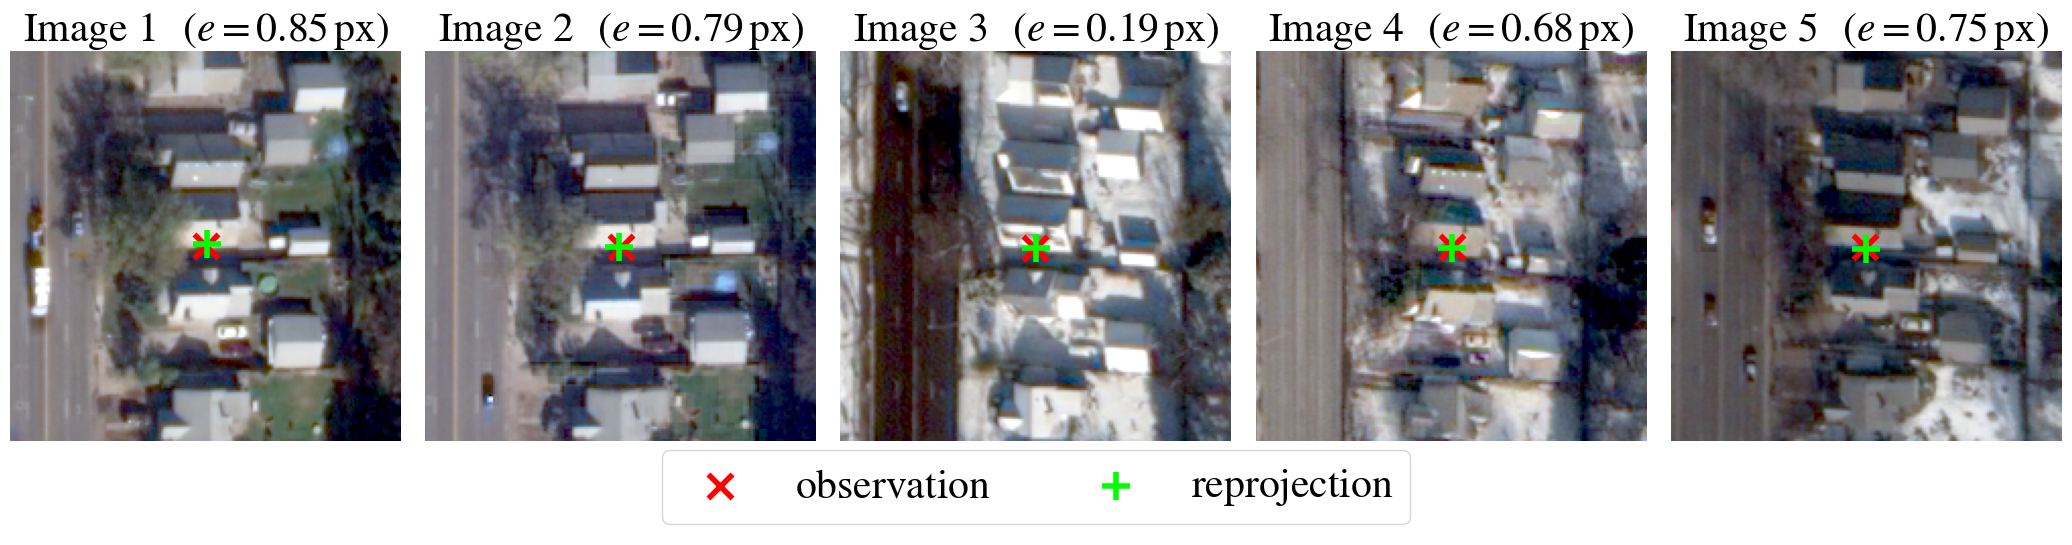

In [102]:
FIGURE_FONT_SIZE = 16
FIGURE_TITLE_SIZE = 18
FIGURE_PANEL_TITLE_SIZE = 30
FIGURE_LEGEND_SIZE = 30

def plot_optimized_reprojected_track(items, crop_radius=CROP_RADIUS):
    fig, axes = plt.subplots(1, 5, figsize=(21, 6))
    for k, (ax, item) in enumerate(zip(axes, items), start=1):
        img = read_image_for_display(item["image_path"])
        crop, obs_cx, obs_cy = extract_crop(img, item["col"], item["row"], crop_radius)
        x0 = item["col"] - obs_cx
        y0 = item["row"] - obs_cy
        proj_cx = item["proj_col"] - x0
        proj_cy = item["proj_row"] - y0

        ax.imshow(crop, cmap="gray" if crop.ndim == 2 else None)
        ax.scatter([obs_cx], [obs_cy], marker="x", s=300, c="red", linewidths=4.0, zorder=3, label=r"$\mathrm{observation}$")
        ax.scatter([proj_cx], [proj_cy], marker="+", s=400, c="lime", linewidths=4.0, zorder=4, label=r"$\mathrm{reprojection}$")
        ax.plot([obs_cx, proj_cx], [obs_cy, proj_cy], color="yellow", linewidth=1.5, zorder=2)
        role = "held-out" if k == 5 else "train"
        role_label = latex_escape(role)
        ax.set_title(
            #rf"$\mathrm{{img}}\ {k}\;(\mathrm{{{role_label}}})$"
            rf"$\mathrm{{Image}}\ {k}\; \;\; $"
            rf"($e={item['error_px']:.2f}\,\mathrm{{px}}$)",
            fontsize=FIGURE_PANEL_TITLE_SIZE,
        )
        ax.set_xlim(0, crop.shape[1])
        ax.set_ylim(crop.shape[0], 0)
        ax.set_aspect("equal")
        ax.axis("off")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=FIGURE_LEGEND_SIZE)
    '''
    fig.suptitle(
        r"$\mathrm{Optimized}\;\mathrm{3D}\;\mathrm{point}\;\mathrm{reprojection};\;\mathrm{optimized}\;\mathrm{on}\;\mathrm{observations}\;1\! -\! 4$",
        fontsize=FIGURE_TITLE_SIZE,
    )
    '''
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()

plot_optimized_reprojected_track(optimized_reprojected)
